<a href="https://colab.research.google.com/github/Awabhssn/My-work/blob/main/Unversty.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
base_path = "/content/school_db_csv"
departments = pd.read_csv(f"{base_path}/departments.csv")
majors = pd.read_csv(f"{base_path}/majors.csv")
professors = pd.read_csv(f"{base_path}/professors.csv", parse_dates=['hire_date'])
students = pd.read_csv(f"{base_path}/students.csv")
courses = pd.read_csv(f"{base_path}/courses.csv")
course_offerings = pd.read_csv(f"{base_path}/course_offerings.csv")
enrollments = pd.read_csv(f"{base_path}/enrollments.csv")
assessment_components = pd.read_csv(f"{base_path}/assessment_components.csv")
student_component_scores = pd.read_csv(f"{base_path}/student_component_scores.csv")
classrooms = pd.read_csv(f"{base_path}/classrooms.csv")
offering_timeslots = pd.read_csv(f"{base_path}/offering_timeslots.csv")
timeslots = pd.read_csv(f"{base_path}/timeslots.csv")
prerequisites = pd.read_csv(f"{base_path}/prerequisites.csv")
evaluations = pd.read_csv(f"{base_path}/evaluations.csv")
evaluation_summary = pd.read_csv(f"{base_path}/evaluation_summary.csv")

In [ ]:
dataframes = {
    "departments": departments,
    "majors": majors,
    "professors": professors,
    "students": students,
    "courses": courses,
    "course_offerings": course_offerings,
    "enrollments": enrollments,
    "assessment_components": assessment_components,
    "student_component_scores": student_component_scores,
    "classrooms": classrooms,
    "offering_timeslots": offering_timeslots,
    "timeslots": timeslots,
    "prerequisites": prerequisites,
    "evaluations": evaluations,
    "evaluation_summary": evaluation_summary}

In [ ]:
for name, df in dataframes.items():
    print(f"\n Data types for table: {name}")
    print(df.dtypes)


 Data types for table: departments
department_id     int64
dept_code        object
name             object
faculty          object
building         object
dtype: object

 Data types for table: majors
major_id          int64
department_id     int64
major_code       object
name             object
dtype: object

 Data types for table: professors
professor_id              int64
department_id             int64
first_name               object
last_name                object
hire_date        datetime64[ns]
rank                     object
dtype: object

 Data types for table: students
student_id     int64
major_id       int64
start_year     int64
gender        object
dob           object
dtype: object

 Data types for table: courses
course_id         int64
department_id     int64
course_code      object
course_name      object
credits           int64
dtype: object

 Data types for table: course_offerings
offering_id      int64
course_id        int64
professor_id     int64
semester        obje

In [ ]:
for name, df in dataframes.items():
    print(f" Missing values in {name}:")
    missing = df.isnull().sum()
    print(missing[missing > 0].sort_values(ascending=False))

 Missing values in departments:
Series([], dtype: int64)
 Missing values in majors:
Series([], dtype: int64)
 Missing values in professors:
Series([], dtype: int64)
 Missing values in students:
Series([], dtype: int64)
 Missing values in courses:
Series([], dtype: int64)
 Missing values in course_offerings:
Series([], dtype: int64)
 Missing values in enrollments:
gpa_points     3
final_score    2
dtype: int64
 Missing values in assessment_components:
Series([], dtype: int64)
 Missing values in student_component_scores:
Series([], dtype: int64)
 Missing values in classrooms:
Series([], dtype: int64)
 Missing values in offering_timeslots:
Series([], dtype: int64)
 Missing values in timeslots:
Series([], dtype: int64)
 Missing values in prerequisites:
Series([], dtype: int64)
 Missing values in evaluations:
Series([], dtype: int64)
 Missing values in evaluation_summary:
Series([], dtype: int64)


In [ ]:
enrollments["final_score"].fillna(0, inplace=True)
enrollments["gpa_points"].fillna(0, inplace=True)

/tmp/ipython-input-3402654313.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  enrollments["final_score"].fillna(0, inplace=True)
/tmp/ipython-input-3402654313.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [ ]:
# check Fk:

# students → majors
print("students → majors:", students[~students["major_id"].isin(majors["major_id"])].shape[0], "missing")
# majors → departments
print("majors → departments:", majors[~majors["department_id"].isin(departments["department_id"])].shape[0], "missing")
# professors → departments
print("professors → departments:", professors[~professors["department_id"].isin(departments["department_id"])].shape[0], "missing")
# courses → departments
print("courses → departments:", courses[~courses["department_id"].isin(departments["department_id"])].shape[0], "missing")
# course_offerings → courses
print("course_offerings → courses:", course_offerings[~course_offerings["course_id"].isin(courses["course_id"])].shape[0], "missing")
# enrollments → students
print("enrollments → students:", enrollments[~enrollments["student_id"].isin(students["student_id"])].shape[0], "missing")
# enrollments → course_offerings
print("enrollments → course_offerings:", enrollments[~enrollments["offering_id"].isin(course_offerings["offering_id"])].shape[0], "missing")
# evaluation_summary → course_offerings
print("evaluation_summary → course_offerings:", evaluation_summary[~evaluation_summary["offering_id"].isin(course_offerings["offering_id"])].shape[0], "missing")


students → majors: 0 missing
majors → departments: 0 missing
professors → departments: 0 missing
courses → departments: 0 missing
course_offerings → courses: 0 missing
enrollments → students: 0 missing
enrollments → course_offerings: 0 missing
evaluation_summary → course_offerings: 0 missing


In [ ]:
#check_weight:
weight_check = (assessment_components.groupby("offering_id")["weight_pct"].sum().reset_index())
invalid_weights = weight_check[weight_check["weight_pct"] != 100]
if invalid_weights.empty:
    print(" All offerings have valid assessment weights (sum to 100%).")
else:
    print("Offerings with invalid weight sums found:")


 All offerings have valid assessment weights (sum to 100%).


In [ ]:
# check_student score:
score_check = student_component_scores.merge(assessment_components[["component_id", "max_points"]],on="component_id",how="left")
invalid_scores = score_check[score_check["score_points"] > score_check["max_points"]]
print(invalid_scores.shape[0])
display(invalid_scores.head())

1


,scs_id,student_id,offering_id,component_id,score_points,max_points
15,16,431,1,1,600.0,100


In [ ]:
# check final_score& gpa_points:
invalid_final = enrollments[enrollments["final_score"] > 100]
invalid_gpa = enrollments[enrollments["gpa_points"] > 4]
print("final_score > 100:", invalid_final.shape[0])
display(invalid_final.head())
print("gpa_points > 4:", invalid_gpa.shape[0])
display(invalid_gpa.head())

final_score > 100: 0


,enrollment_id,student_id,offering_id,grade,final_score,gpa_points


gpa_points > 4: 2


,enrollment_id,student_id,offering_id,grade,final_score,gpa_points
1,2,391,1,A,91.42,7.0
267,268,212,9,B,85.36,5.0


In [ ]:
#check_responses:
invalid_eval = evaluation_summary[evaluation_summary["responses"] > evaluation_summary["n_enrolled"]]
print("responses > n_enrolled:", invalid_eval.shape[0])


responses > n_enrolled: 0


In [ ]:
students_majors = students.merge(
    majors, on="major_id", how="left")
enrollments_students = enrollments.merge(
    students_majors, on="student_id", how="left")
offerings_courses = course_offerings.merge(
    courses, on="course_id", how="left")
enrollments_full = enrollments_students.merge(
    offerings_courses, on="offering_id", how="left")
components_scores = student_component_scores.merge(
    assessment_components, on=["offering_id", "component_id"], how="left")
merged_df = enrollments_full.merge(
    components_scores, on=["student_id", "offering_id"], how="left")

print("merged")
merged_df.head()

merged


,enrollment_id,student_id,offering_id,grade,final_score,gpa_points,major_id,start_year,gender,dob,...,course_code,course_name,credits,scs_id,component_id,score_points,name_y,weight_pct,max_points,due_week
0,1,513,1,C,70.91,2.0,6,2024,F,5/18/1997,...,EE101,Foundations of Control,4,1,1,69.452792,Homework,25,100,2
1,1,513,1,C,70.91,2.0,6,2024,F,5/18/1997,...,EE101,Foundations of Control,4,2,2,71.634857,Project,35,100,4
2,1,513,1,C,70.91,2.0,6,2024,F,5/18/1997,...,EE101,Foundations of Control,4,3,3,71.175458,Final,40,100,6
3,2,391,1,A,91.42,7.0,14,2025,M,2/1/2006,...,EE101,Foundations of Control,4,4,1,88.724859,Homework,25,100,2
4,2,391,1,A,91.42,7.0,14,2025,M,2/1/2006,...,EE101,Foundations of Control,4,5,2,83.545079,Project,35,100,4


In [ ]:
# Final_scores:
merged = student_component_scores.merge(assessment_components,on=["offering_id", "component_id"], how="left")
merged["component_pct"] = merged["score_points"] / merged["max_points"]
merged["weighted_component"] = merged["component_pct"] * merged["weight_pct"]

final_scores = (
    merged.groupby(["student_id", "offering_id"], as_index=False)
    .agg(weighted_final_score=("weighted_component", "sum")))

final_scores["final_score"] = final_scores["weighted_final_score"] * 100

print(" Final scores computed successfully")
display(final_scores.head())

 Final scores computed successfully


,student_id,offering_id,weighted_final_score,final_score
0,1,9,67.508057,6750.805739
1,1,26,81.142495,8114.249533
2,1,35,68.270131,6827.013105
3,1,40,76.864634,7686.463410
4,1,60,63.475963,6347.596251


In [ ]:
# Build offering-level aggregates:
merged = enrollments_full.merge(final_scores, on=["student_id", "offering_id"], how="left")
merged["final_score_used"] = merged["final_score_y"]
offering_stats = merged.groupby("offering_id").agg(n_students=("student_id", "nunique"),avg_final_score=("final_score_used", "mean"),
pass_rate=("final_score_used", lambda x: (x >= 60).mean())).reset_index()

if "capacity" in course_offerings.columns:
    offering_stats = offering_stats.merge(course_offerings[["offering_id", "capacity"]],on="offering_id",how="left")
    offering_stats["utilization_rate"] = (offering_stats["n_students"] / offering_stats["capacity"])

offering_stats.to_csv("/content/offering_aggregates.csv", index=False)


display(offering_stats.head(10))

,offering_id,n_students,avg_final_score,pass_rate,capacity,utilization_rate
0,1,26,7543.166685,1.0,28,0.928571
1,2,45,7893.550097,1.0,59,0.762712
2,3,42,7181.471324,1.0,55,0.763636
3,4,23,6728.647529,1.0,27,0.851852
4,5,25,6959.679881,1.0,34,0.735294
5,6,23,8164.327069,1.0,35,0.657143
6,7,23,8436.351483,1.0,27,0.851852
7,8,44,6804.994648,1.0,52,0.846154
8,9,30,7004.200266,1.0,41,0.731707
9,10,39,6631.351459,1.0,49,0.795918


In [ ]:
# Student_profile:
student_data = (
    enrollments
    .merge(final_scores, on=["student_id", "offering_id"], how="left")
    .merge(course_offerings[["offering_id", "course_id"]], on="offering_id", how="left")
    .merge(courses[["course_id", "credits"]], on="course_id", how="left")
    .merge(students[["student_id", "major_id", "start_year"]], on="student_id", how="left")
    .merge(majors[["major_id", "name"]].rename(columns={"name": "major"}), on="major_id", how="left"))
student_data["credits_attempted"] = student_data["credits"].fillna(0)
student_profile = (student_data.groupby(["student_id", "major", "start_year"])
    .agg( total_credits_attempted=("credits_attempted", "sum"),mean_final_score=("final_score_x", "mean"),).reset_index())
def score_to_gpa(score):
    if pd.isna(score): return np.nan
    if score >= 90: return 4.0
    elif score >= 80: return 3.0
    elif score >= 70: return 2.0
    elif score >= 60: return 1.0
    else: return 0.0

student_profile["cumulative_GPA"] = student_profile["mean_final_score"].apply(score_to_gpa)
student_profile.to_csv("student_profile.csv", index=False)
display(student_profile.head(10))

,student_id,major,start_year,total_credits_attempted,mean_final_score,cumulative_GPA
0,1,2 Major 4,2022,16,71.452000,2.0
1,2,2 Major 1,2024,6,71.440000,2.0
2,3,2 Major 4,2021,7,63.190000,1.0
3,4,1 Major 2,2021,4,95.980000,4.0
4,5,2 Major 2,2024,14,58.980000,0.0
5,6,4 Major 1,2021,15,75.658000,2.0
6,7,4 Major 1,2023,18,76.671667,2.0
7,8,5 Major 4,2024,10,89.480000,3.0
8,9,2 Major 3,2021,12,83.895000,3.0
9,10,0 Major 2,2021,16,65.904000,1.0


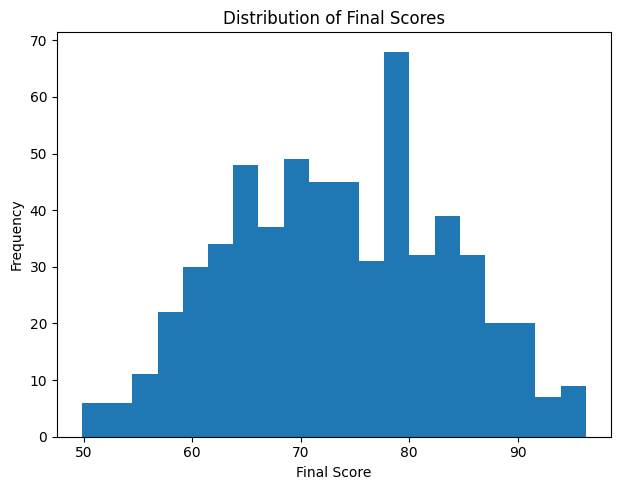

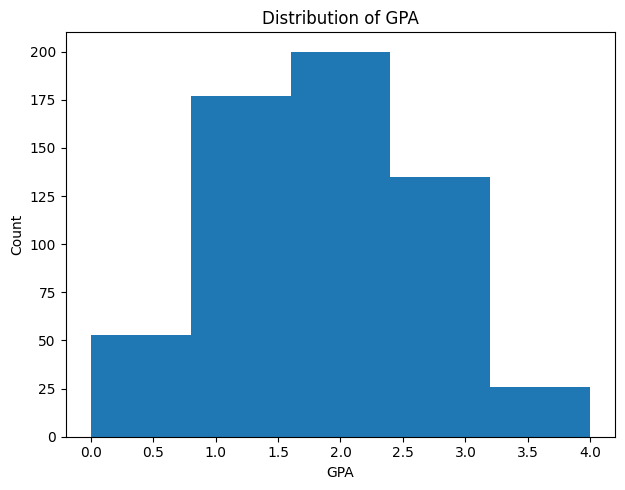

In [ ]:
# Histograms of final_score, GPA:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(student_profile["mean_final_score"], bins=20)
plt.title("Distribution of Final Scores")
plt.xlabel("Final Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.subplot(1,2,2)
plt.hist(student_profile["cumulative_GPA"], bins=5)
plt.title("Distribution of GPA")
plt.xlabel("GPA")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

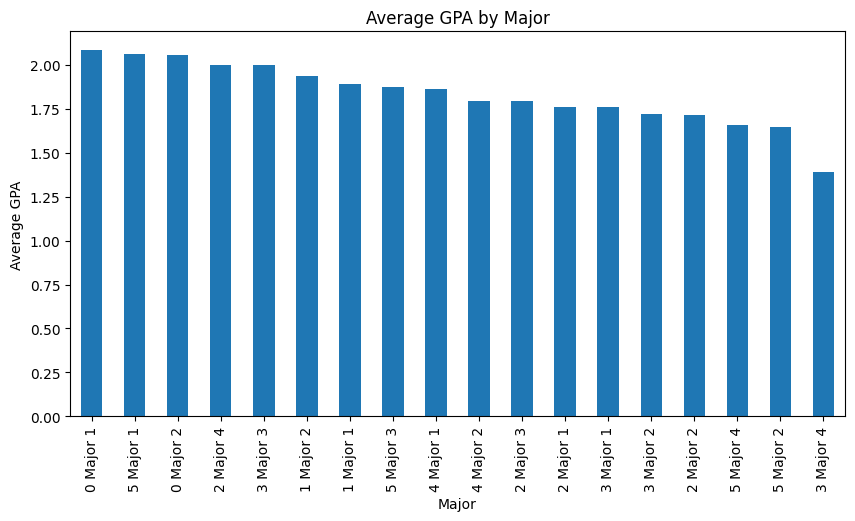

In [ ]:
# Avg GPA by major:
avg_gpa_major = (student_profile.groupby("major")["cumulative_GPA"].mean().sort_values(ascending=False))
avg_gpa_major.plot(kind="bar", figsize=(10,5), title="Average GPA by Major")
plt.xlabel("Major")
plt.ylabel("Average GPA")
plt.show()

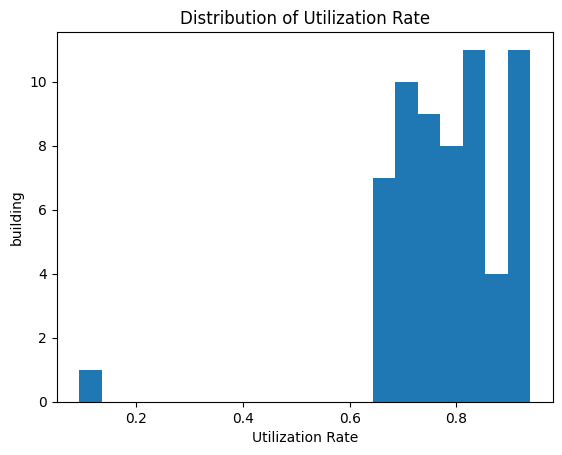

In [ ]:
enrollment_count = enrollments.groupby("offering_id").size().reset_index(name="num_enrolled")
util = course_offerings.merge(enrollment_count, on="offering_id", how="left")
util["utilization_rate"] = util["num_enrolled"] / util["capacity"]
overall_utilization = util["utilization_rate"].mean()
plt.hist(util["utilization_rate"].dropna(), bins=20)
plt.title("Distribution of Utilization Rate")
plt.xlabel("Utilization Rate")
plt.ylabel("building")
plt.show()

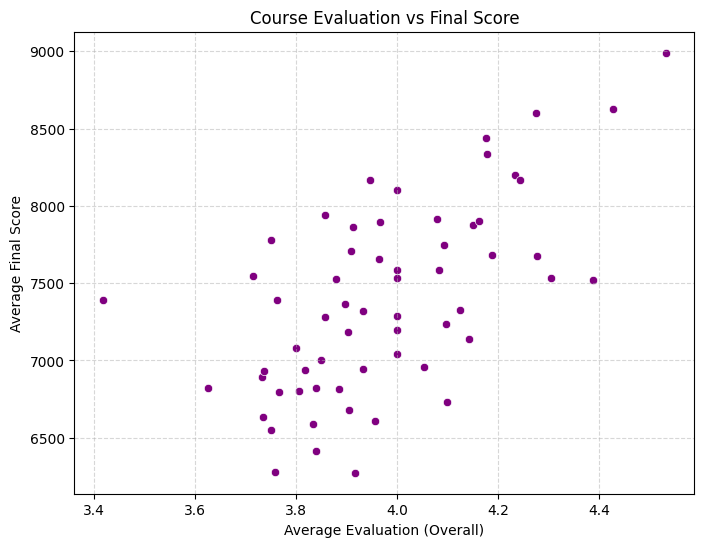

In [ ]:
# Relationship plots: avg_overall (evals) vs avg_final_score (offerings):
avg_final_per_offering = (final_scores.groupby("offering_id")["final_score"].mean().reset_index())
eval_vs_score = evaluation_summary.merge(avg_final_per_offering, on="offering_id", how="left")
plt.figure(figsize=(8, 6))
sns.scatterplot(x="avg_overall", y="final_score", data=eval_vs_score, color="purple")
plt.title("Course Evaluation vs Final Score")
plt.xlabel("Average Evaluation (Overall)")
plt.ylabel("Average Final Score")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


In [ ]:
# side by side:
eval_summary_py = evaluations.groupby('offering_id').agg(
    responses=('evaluation_id', 'count'),
    avg_overall=('q_overall', 'mean'),
    avg_clarity=('q_clarity', 'mean'),
    avg_organization=('q_organization', 'mean'),
    avg_engagement=('q_engagement', 'mean'),
    avg_feedback=('q_feedback', 'mean'),
    avg_difficulty=('q_difficulty', 'mean')
).reset_index()
enrollment_counts = enrollments.groupby('offering_id')['student_id'].nunique().reset_index()
enrollment_counts.columns = ['offering_id', 'n_enrolled']
eval_summary_py = eval_summary_py.merge(enrollment_counts, on='offering_id', how='left')
eval_summary_py['resp_rate'] = (eval_summary_py['responses'] / eval_summary_py['n_enrolled']) * 100
eval_summary_py = eval_summary_py.round(2)
comparison = eval_summary_py.merge(
    evaluation_summary,
    on='offering_id',
    suffixes=('_py', '_provided'))

print("Reconciliation Report: Python vs Provided Evaluation Summary")
print("=" * 60)
print(f"Total offerings compared: {len(comparison)}")
print()
metrics_to_compare = [
    'responses', 'resp_rate', 'avg_overall', 'avg_clarity',
    'avg_organization', 'avg_engagement', 'avg_feedback', 'avg_difficulty']

Reconciliation Report: Python vs Provided Evaluation Summary
Total offerings compared: 61



In [ ]:
comparison

,offering_id,responses_py,avg_overall_py,avg_clarity_py,avg_organization_py,avg_engagement_py,avg_feedback_py,avg_difficulty_py,n_enrolled_py,resp_rate_py,responses_provided,n_enrolled_provided,resp_rate_provided,avg_overall_provided,avg_clarity_provided,avg_organization_provided,avg_engagement_provided,avg_feedback_provided,avg_difficulty_provided
0,1,21,3.71,4.10,4.00,3.95,4.05,2.10,26,80.77,21,26,0.808,3.714286,4.095238,4.000000,3.952381,4.047619,2.095238
1,2,30,3.97,4.10,3.83,4.23,3.93,2.03,45,66.67,30,45,0.667,3.966667,4.100000,3.833333,4.233333,3.933333,2.033333
2,3,31,3.90,4.00,4.00,3.94,3.97,2.32,42,73.81,31,42,0.738,3.903226,4.000000,4.000000,3.935484,3.967742,2.322581
3,4,20,4.10,3.80,3.70,3.75,3.95,2.25,23,86.96,20,23,0.870,4.100000,3.800000,3.700000,3.750000,3.950000,2.250000
4,5,19,4.05,3.84,3.89,4.00,3.89,2.05,25,76.00,19,25,0.760,4.052632,3.842105,3.894737,4.000000,3.894737,2.052632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,57,24,4.12,4.17,3.75,3.79,4.08,2.04,34,70.59,24,34,0.706,4.125000,4.166667,3.750000,3.791667,4.083333,2.041667
57,58,23,3.96,3.87,3.61,4.09,3.78,2.48,35,65.71,23,35,0.657,3.956522,3.869565,3.608696,4.086957,3.782609,2.478261
58,59,43,4.16,4.16,3.81,4.28,3.95,1.88,56,76.79,43,56,0.768,4.162791,4.162791,3.813953,4.279070,3.953488,1.883721
59,60,32,4.00,3.84,4.00,4.00,4.00,2.16,37,86.49,32,37,0.865,4.000000,3.843750,4.000000,4.000000,4.000000,2.156250
